# NB 03 — Exploratory Data Analysis

**Phase 2 — Task 2.3**

Produces:
- Statistical analysis: avg words per split × model
- Top-10 frequent words per class, per split, per model
- Zipf-like word frequency distribution — log-log rank vs frequency
- Arabic word clouds by class, by split × class, by split × model
- N-gram frequency (unigrams, bigrams, trigrams) by class / split × class / split × model
- Vocabulary richness (TTR)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, importlib
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)


Mounted at /content/drive


In [ ]:
import importlib
from src.utils import (
    create_spark_session, load_checkpoint, add_src_to_spark,
    FIGURES_DIR, SOURCE_COL, SPLIT_COL, LABEL_COL, TEXT_COL,
)
from src.data_preparation import remove_non_arabic_noise, tokenize_arabic_text, remove_arabic_stopwords
from src.data_preparation import mapreduce_ngram_frequency
from pyspark.sql.types import StringType
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.font_manager import FontProperties
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud

spark = create_spark_session('ArabicAIDetection_EDA')
add_src_to_spark(spark)

# Colour map: human = black, each AI model gets a colour
MODEL_COLOURS = {
    'human':  '#000000',
    'allam':  '#1f77b4',
    'jais':   '#ff7f0e',
    'llama':  '#2ca02c',
    'openai': '#d62728',
}
MODEL_MARKERS = {
    'human': 'None', 'allam': 'o', 'jais': 's', 'llama': '^', 'openai': 'D',
}

preprocessed_df = load_checkpoint(spark, 'preprocessed')
preprocessed_df.cache()
print(f'Loaded {preprocessed_df.count():,} rows')
preprocessed_df.printSchema()

Loaded 41,940 rows
root
 |-- text: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- source_model: string (nullable = true)
 |-- generation_method: string (nullable = true)
 |-- clean_text: string (nullable = true)



### Arabic font setup

In [ ]:
%%capture
!pip install -q ar_wordcloud arabic-reshaper python-bidi
!apt-get -qq install -y fonts-noto-core fonts-noto-extra fonts-hosny-amiri

In [ ]:
import subprocess, arabic_reshaper
from bidi.algorithm import get_display

def get_font_path(name='Amiri'):
    try:
        return subprocess.check_output(['fc-match', '-f', '%{file}', name], text=True).strip()
    except Exception:
        return None

FONT_PATH = get_font_path('Amiri') or get_font_path('Noto Sans Arabic')
ARABIC_FONT = FontProperties(fname=FONT_PATH) if FONT_PATH else None
print('Arabic font:', FONT_PATH)

def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

Arabic font: /usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Regular.ttf


## 1. Statistical Analysis — Average Word Count

Replicates the per-split, per-model word-count

── Average word count per source model × generation method ──
generation_method  by_polishing  from_title  from_title_and_content
source_model                                                       
allam                     104.2        77.2                    95.3
human                     119.2       119.1                   119.2
jais                       68.5        62.3                   105.7
llama                     102.3        99.9                   103.2
openai                    165.0       123.3                   113.9


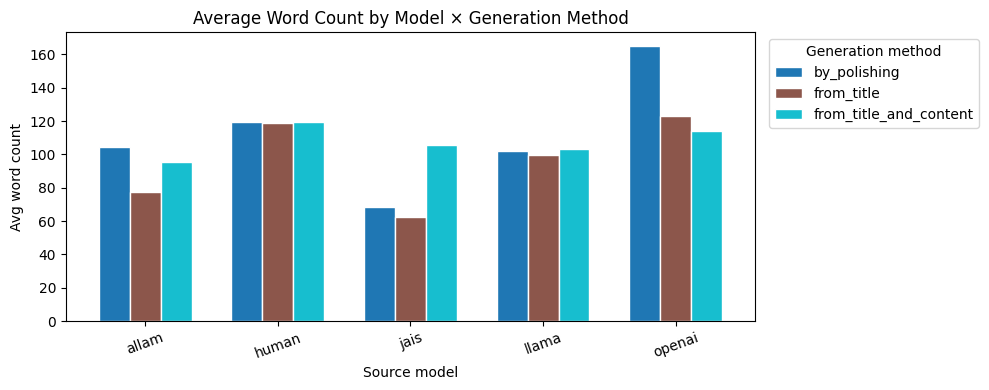

In [ ]:
# Compute avg word count by split_name × source_model (raw text)
avg_words = (
    preprocessed_df
    .withColumn('word_count', F.size(F.split(F.col(TEXT_COL), r'\s+')))
    .groupBy(SPLIT_COL, SOURCE_COL)
    .agg(F.avg('word_count').alias('avg_words'),
         F.stddev('word_count').alias('std_words'),
         F.count('*').alias('n_docs'))
    .orderBy(SPLIT_COL, SOURCE_COL)
    .toPandas()
)

pivot = avg_words.pivot(index=SOURCE_COL, columns=SPLIT_COL, values='avg_words').round(1)
print('── Average word count per source model × generation method ──')
print(pivot.to_string())
pivot.to_csv(str(FIGURES_DIR / 'avg_word_count_table.csv'))

fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.7)
ax.set_xlabel('Source model'); ax.set_ylabel('Avg word count')
ax.set_title('Average Word Count by Model × Generation Method')
ax.legend(title='Generation method', bbox_to_anchor=(1.01, 1))
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'avg_word_count_by_model_split.png'), dpi=150)
plt.show()


## 2. Top-10 Frequent Words (Table 4 equivalent)

For each combination of generation method × source model, shows the top-10
most frequent words **after stop-word removal** (same approach as the paper).

In [ ]:
def top_words_for(df, text_col="clean_text", top_k=10):
    """Compute top-k word frequencies from a Spark DataFrame group."""
    word_counts = (
        df.select(F.explode(F.split(F.col(text_col), r'\s+')).alias('word'))
          .filter(F.col('word') != '')
          .groupBy('word').count()
          .orderBy(F.col('count').desc())
          .limit(top_k)
          .toPandas()
    )
    return word_counts

print('Computing top words by class (Human vs AI) …')
for label_val, label_name in [(0, 'Human'), (1, 'AI')]:
    sub = preprocessed_df.filter(F.col(LABEL_COL) == label_val)
    top = top_words_for(sub, top_k=10)
    print(f'\n── Top 10 words [{label_name}] ──')
    for rank, (_, row) in enumerate(top.iterrows(), 1):
        print(f'  {rank:2d}. {row["word"]:20s} ({row["count"]:,})')


Computing top words by class (Human vs AI) …

── Top 10 words [Human] ──
   1. دراسه                (6,567)
   2. بحث                  (2,689)
   3. مجتمع                (1,972)
   4. اهم                  (1,923)
   5. جزائر                (1,902)
   6. مستوي                (1,829)
   7. لغه                  (1,811)
   8. جزائري               (1,703)
   9. خاصه                 (1,687)
  10. عربيه                (1,642)

── Top 10 words [AI] ──
   1. دراسه                (48,053)
   2. بحث                  (40,199)
   3. تحليل                (16,094)
   4. نتائج                (14,721)
   5. تهدف                 (11,854)
   6. تاثير                (11,519)
   7. فهم                  (11,256)
   8. اهميه                (11,051)
   9. ضوء                  (10,203)
  10. دور                  (10,014)


In [ ]:
# Top-10 by split × model — mirrors Table 4 structure
print('Computing top words by generation method × model …')
all_splits  = [r['generation_method'] for r in preprocessed_df.select(SPLIT_COL).distinct().collect()]
all_models  = [r['source_model']      for r in preprocessed_df.select(SOURCE_COL).distinct().collect()]

top_word_data = {}
for split in sorted(all_splits):
    for model in sorted(all_models):
        sub = preprocessed_df.filter(
            (F.col(SPLIT_COL) == split) & (F.col(SOURCE_COL) == model)
        )
        if sub.count() > 0:
            top_word_data[(split, model)] = top_words_for(sub, top_k=10)

# Pretty-print one split as sample (by_polishing = closest to Table 4)
sample_split = 'by_polishing'
print(f'\n── Top-10 words for split: {sample_split} ──')
header = f'{"Rank":>4} ' + ' '.join(f'{m:>14}' for m in sorted(all_models))
print(header)
print('─' * (len(header) + 4))
for rank in range(1, 11):
    row_str = f'{rank:>4} '
    for model in sorted(all_models):
        key = (sample_split, model)
        if key in top_word_data and rank <= len(top_word_data[key]):
            w = top_word_data[key].iloc[rank-1]['word']
            c = top_word_data[key].iloc[rank-1]['count']
            row_str += f' {w:>8}({c:>5})'
        else:
            row_str += ' ' * 15
    print(row_str)


Computing top words by generation method × model …

── Top-10 words for split: by_polishing ──
Rank          allam          human           jais          llama         openai
───────────────────────────────────────────────────────────────────────────────────
   1     دراسه( 4344)    دراسه( 2263)    دراسه( 1847)      بحث( 3063)    دراسه( 4356)
   2       بحث( 2371)      بحث(  901)    تركيز(  938)    دراسه( 2833)      بحث( 2909)
   3     تحليل( 1289)    جزائر(  657)     تدرس(  789)    اهميه( 1200)    تحليل( 1831)
   4      تهدف( 1119)    مجتمع(  656)      بحث(  690)    تركيز(  935)    تعزيز( 1439)
   5       ضوء( 1001)      اهم(  643)      دور(  513)      ضوء(  813)    اهميه( 1340)
   6     تاثير(  870)    مستوي(  635)     بشكل(  513)      حول(  786)      فهم( 1320)
   7      بشكل(  795)      لغه(  628)  استخدام(  501)     يبرز(  764)      ضوء( 1268)
   8     تركيز(  765)   جزائري(  577)    تاثير(  495)     يهدف(  705)    تاثير( 1173)
   9       فهم(  757)     خاصه(  577)    جزائر(  489)

## 3. Zipf-like Word Frequency Distribution

Log-log plot of word rank vs frequency for human and each AI model,
split by generation method.
- Human = black solid line
- Each AI model = distinct coloured marker
- X: word rank (log), Y: frequency (log)

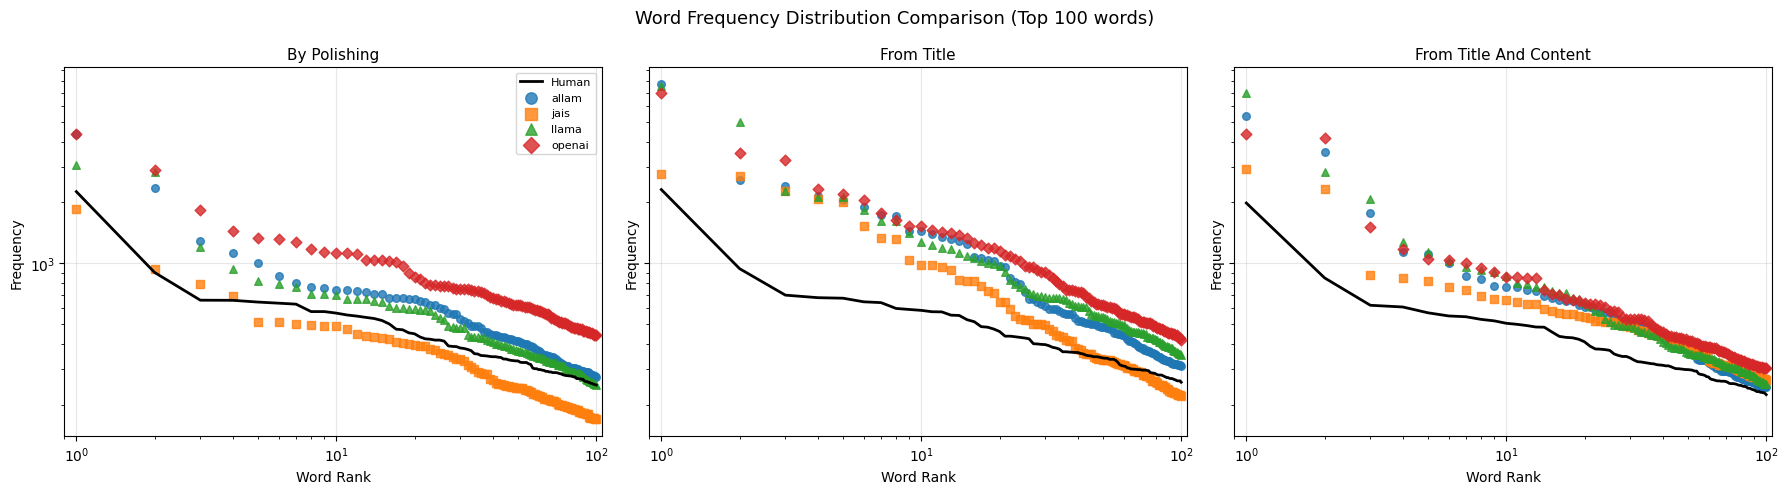

Saved: zipf_word_freq_distribution.png


In [ ]:
def get_top_n_freq(df, text_col='clean_text', n=100):
    """Return the top-n word frequencies as a sorted list."""
    wc = (
        df.select(F.explode(F.split(F.col(text_col), r'\s+')).alias('word'))
          .filter(F.col('word') != '')
          .groupBy('word').count()
          .orderBy(F.col('count').desc())
          .limit(n)
          .toPandas()
    )
    return wc['count'].tolist()

TOP_N = 100
splits = sorted(all_splits)

fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 5), sharey=True)
if len(splits) == 1:
    axes = [axes]

for ax, split in zip(axes, splits):
    # Human — black solid line
    human_sub = preprocessed_df.filter(
        (F.col(SPLIT_COL) == split) & (F.col(SOURCE_COL) == 'human')
    )
    human_freq = get_top_n_freq(human_sub, n=TOP_N)
    ranks = list(range(1, len(human_freq) + 1))
    ax.plot(ranks, human_freq, '-', color='black', lw=2, label='Human', zorder=5)

    # Each AI model — coloured marker
    for model in sorted([m for m in all_models if m != 'human']):
        model_sub = preprocessed_df.filter(
            (F.col(SPLIT_COL) == split) & (F.col(SOURCE_COL) == model)
        )
        if model_sub.count() == 0:
            continue
        freq = get_top_n_freq(model_sub, n=TOP_N)
        rk = list(range(1, len(freq) + 1))
        ax.scatter(rk, freq,
                   color=MODEL_COLOURS.get(model, 'gray'),
                   marker=MODEL_MARKERS.get(model, 'o'),
                   s=30, alpha=0.8, label=model, zorder=4)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.9, TOP_N + 5)
    ax.set_xlabel('Word Rank', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(split.replace('_', ' ').title(), fontsize=11)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle('Word Frequency Distribution Comparison (Top 100 words)', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'zipf_word_freq_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: zipf_word_freq_distribution.png')


## 4. Arabic Word Clouds


In [ ]:
def make_wordcloud_(df, text_col='clean_text', ax=None, top_k=300):
    freq_pdf = (
        df.select(F.explode(F.split(F.col(text_col), r"\s+")).alias("word"))
        .filter(F.col("word") != "")
        .groupBy("word")
        .count()
        .orderBy(F.col("count").desc())
        .limit(top_k)
        .toPandas()
    )

    freq = dict(zip(freq_pdf["word"], freq_pdf["count"]))

    wc = WordCloud(
        width=700,
        height=380,
        background_color="white",
        font_path=FONT_PATH,
        prefer_horizontal=0.9,
        max_words=200,
        collocations=False
    ).generate_from_frequencies(freq)

    if ax:
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")

    return wc

In [ ]:
for ax, (label_name, label_val) in zip(axes, label_order):
    sub = preprocessed_df.filter(F.col(LABEL_COL) == label_val)
    make_wordcloud_(sub, text_col='clean_text', ax=ax, top_k=300)
    ax.set_title(label_name, fontsize=13)

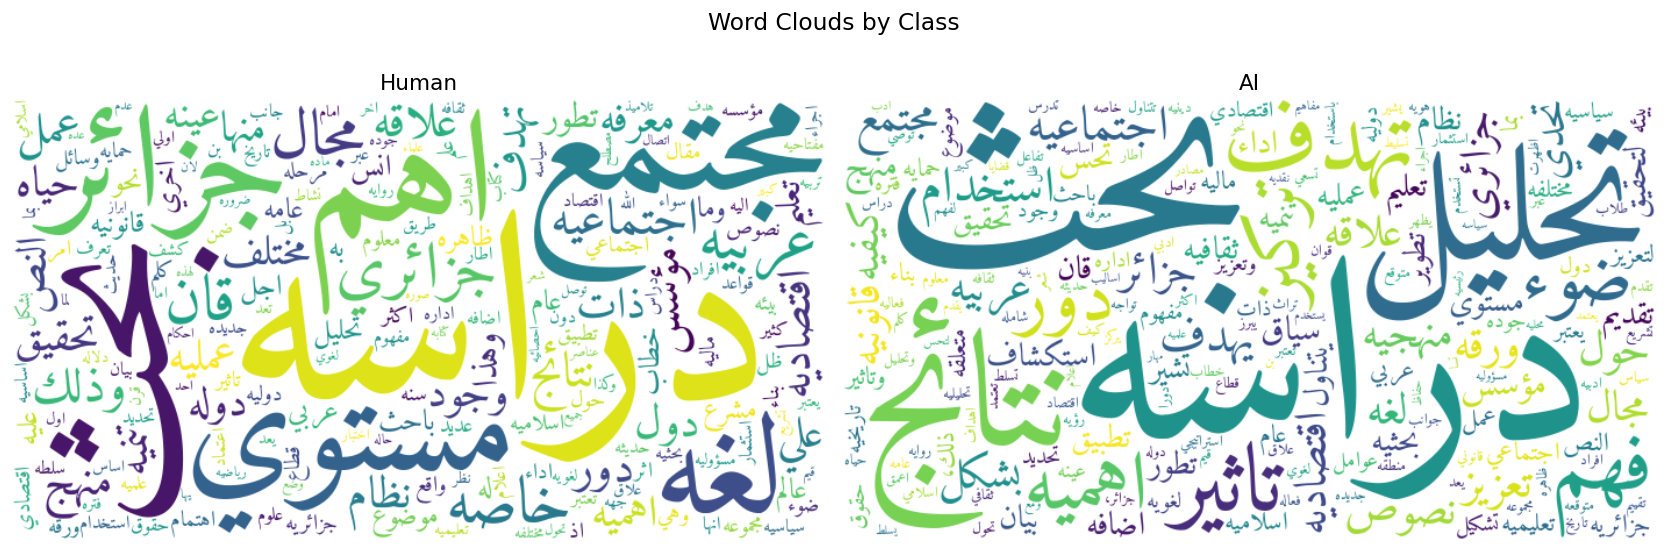

In [ ]:
label_order = [("Human", 0), ("AI", 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for ax, (label_name, label_val) in zip(axes, label_order):
    sub = preprocessed_df.filter(F.col(LABEL_COL) == label_val)

    make_wordcloud_(
        sub,
        text_col='clean_text',
        ax=ax
    )

    ax.set_title(label_name, fontsize=13)

fig.suptitle("Word Clouds by Class", fontsize=14)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "wordclouds_by_class.png"), dpi=150)
plt.show()

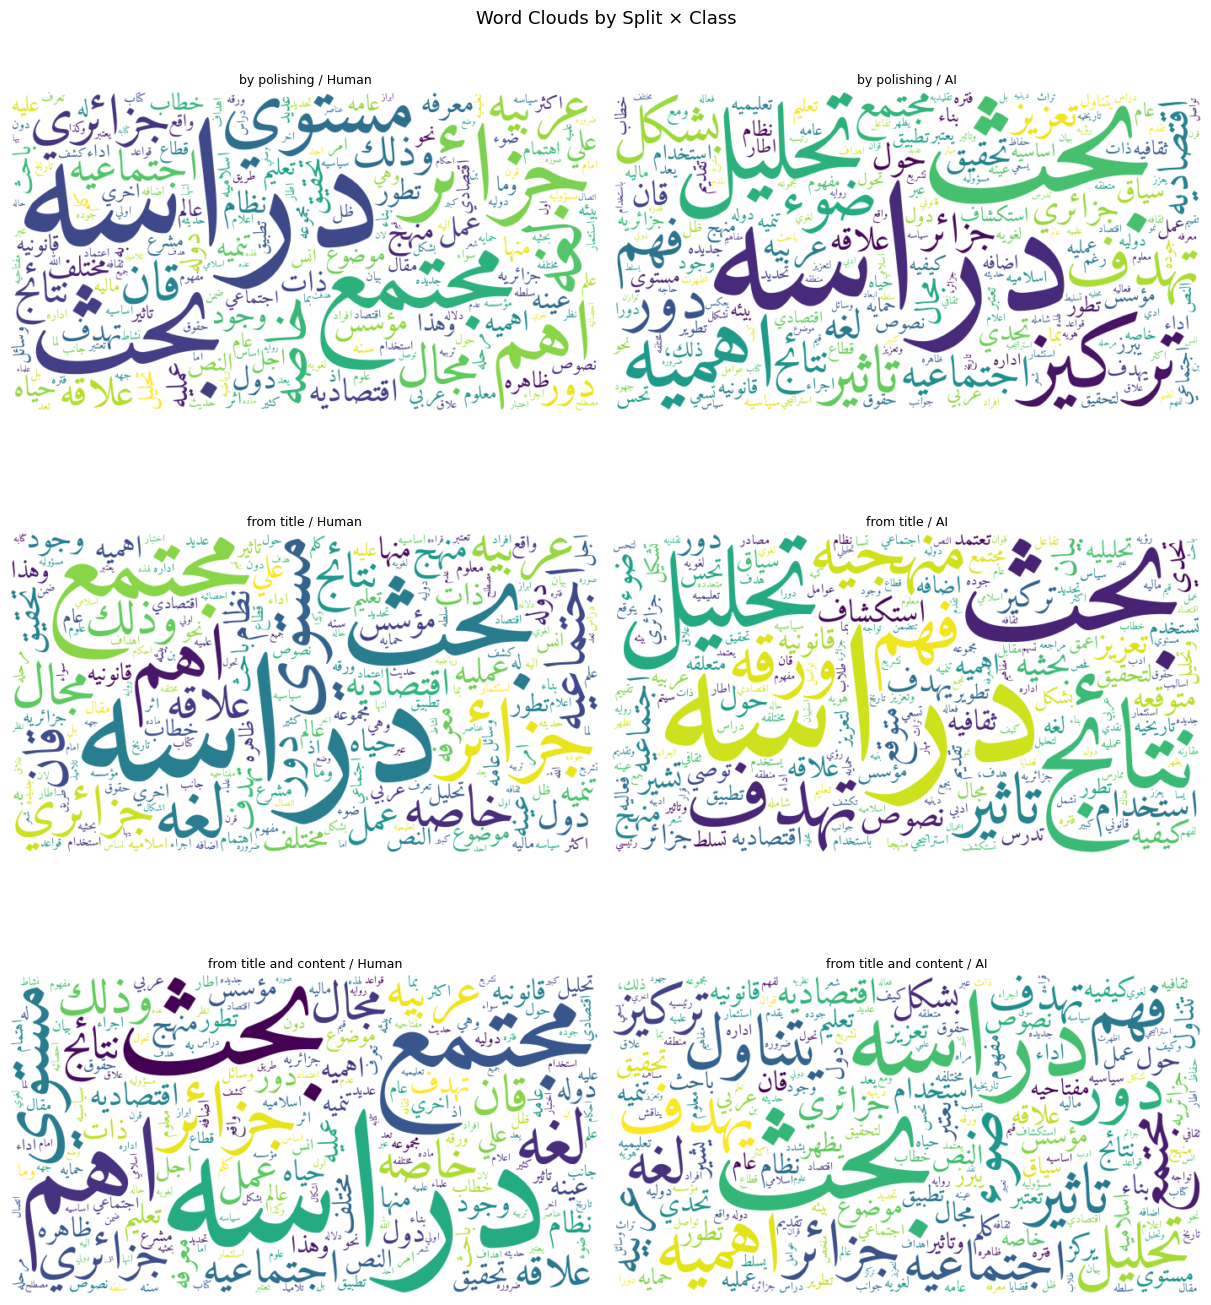

In [ ]:
# By split × class
split_order = sorted(all_splits)
fig, axes = plt.subplots(len(split_order), 2,
                         figsize=(12, 4.5 * len(split_order)), dpi=100,
                         constrained_layout=True)

for i, split in enumerate(split_order):
    for j, (label_name, label_val) in enumerate(label_order):
        ax = axes[i][j]
        sub = preprocessed_df.filter(
            (F.col(SPLIT_COL) == split) & (F.col(LABEL_COL) == label_val)
        )
        make_wordcloud_(sub, ax=ax)
        ax.set_title(f'{split.replace("_"," ")} / {label_name}', fontsize=9)

fig.suptitle('Word Clouds by Split × Class', fontsize=13)
fig.savefig(str(FIGURES_DIR / 'wordclouds_by_split_class.png'), dpi=120)
plt.show()


## 5. N-gram Frequency Analysis (Unigrams, Bigrams, Trigrams)


/tmp/ipykernel_37540/1505152347.py:19: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.savefig(str(FIGURES_DIR / f'ngrams_{label_name.lower()}.png'), dpi=120)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


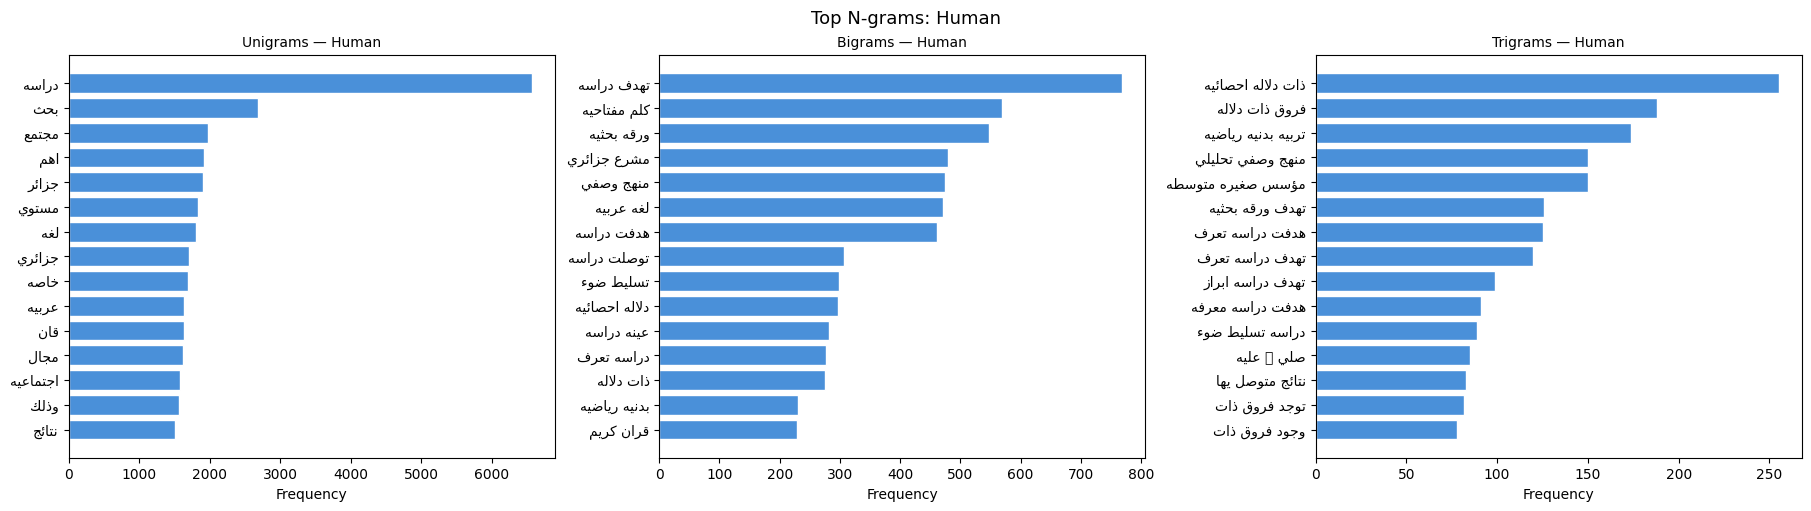

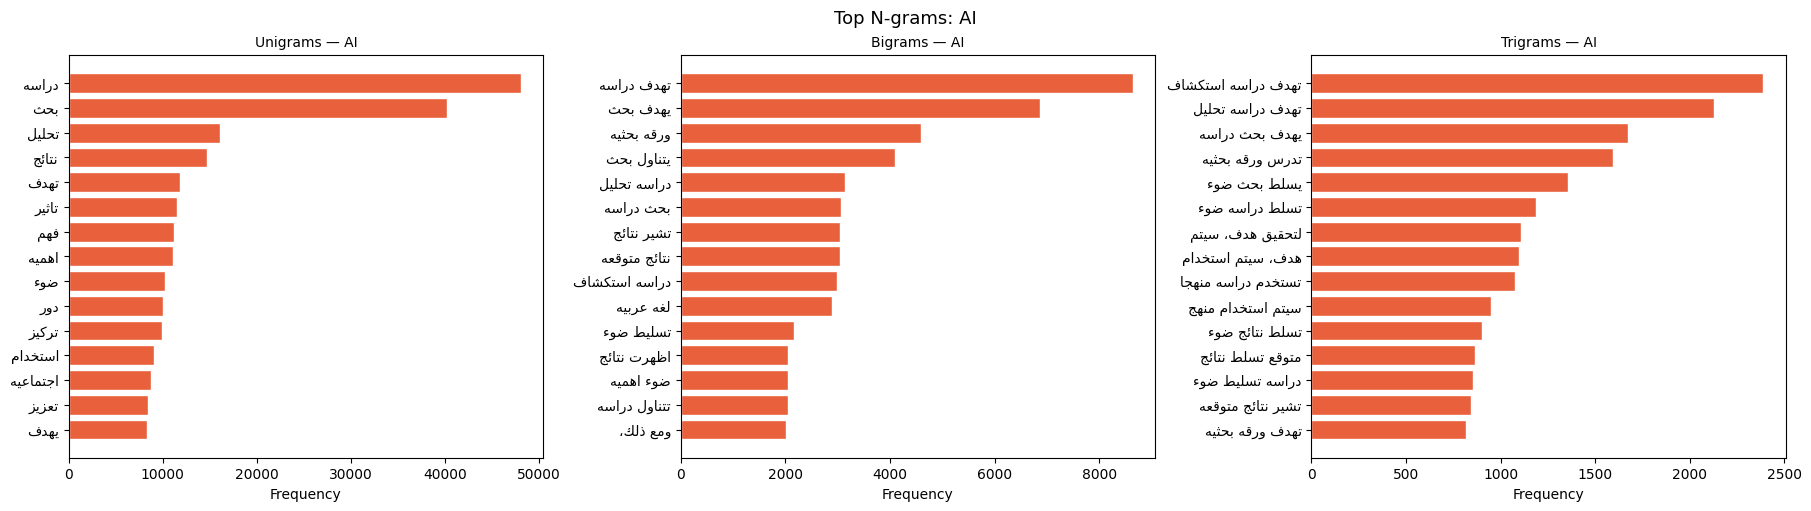

In [ ]:

def plot_top_ngrams(df, n, top_k=15, title='', ax=None, color='#4A90D9'):
    ngram_df = mapreduce_ngram_frequency(df, n=n, text_col='clean_text').limit(top_k).toPandas()
    ngram_df = ngram_df.sort_values('count')
    labels   = [fix_arabic(g) for g in ngram_df['ngram']]
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(labels, ngram_df['count'], color=color, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Frequency')
    return ax

# By class — unigrams / bigrams / trigrams side-by-side
for label_val, label_name, color in [(0, 'Human', '#4A90D9'), (1, 'AI', '#E8603C')]:
    sub = preprocessed_df.filter(F.col(LABEL_COL) == label_val)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100, constrained_layout=True)
    for ax, n, label in zip(axes, [1, 2, 3], ['Unigrams', 'Bigrams', 'Trigrams']):
        plot_top_ngrams(sub, n=n, top_k=15, title=f'{label} — {label_name}', ax=ax, color=color)
    fig.suptitle(f'Top N-grams: {label_name}', fontsize=13)
    fig.savefig(str(FIGURES_DIR / f'ngrams_{label_name.lower()}.png'), dpi=120)
    plt.show()


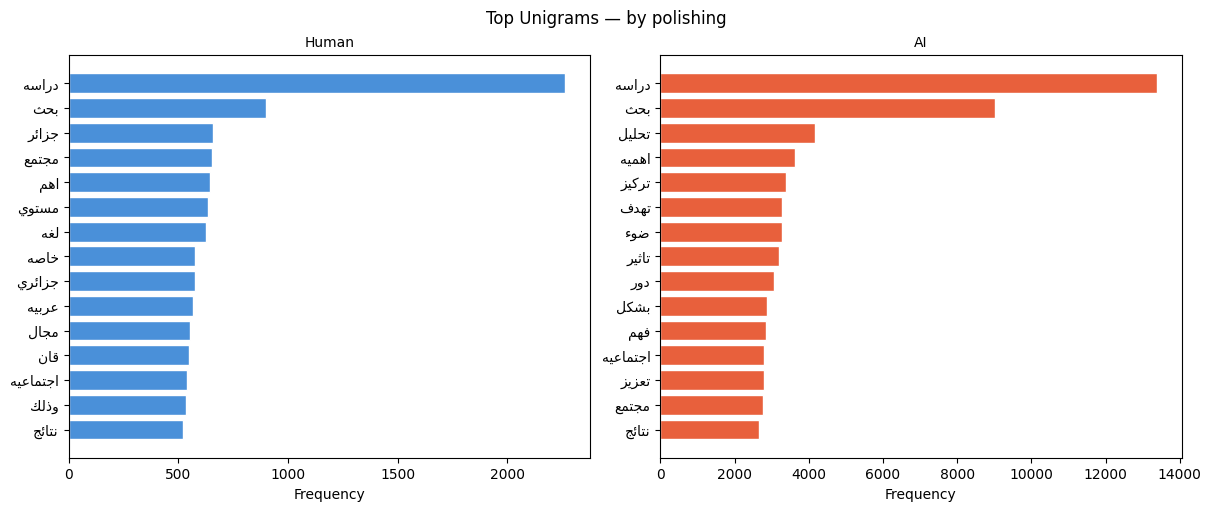

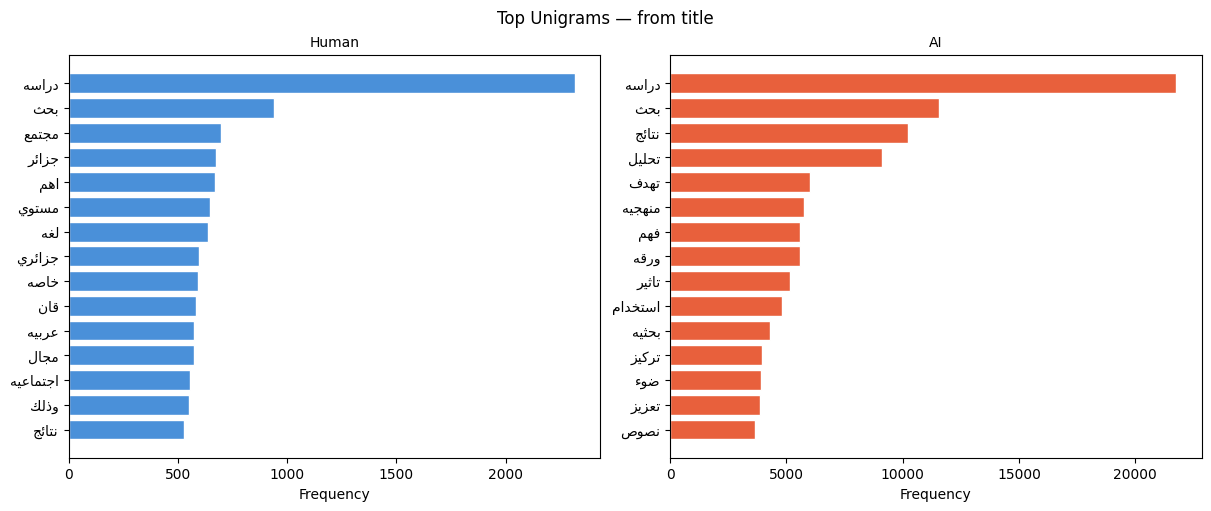

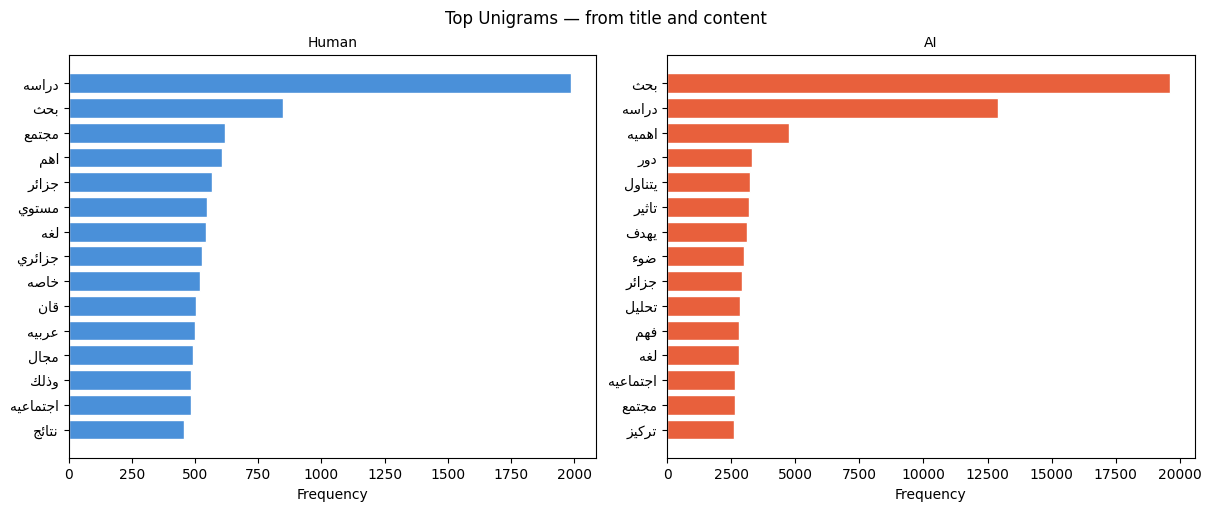

In [ ]:
# By generation method × class — unigrams only
for split in sorted(all_splits):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100, constrained_layout=True)
    for ax, (label_name, label_val, color) in zip(axes, [
        ('Human', 0, '#4A90D9'), ('AI', 1, '#E8603C')
    ]):
        sub = preprocessed_df.filter(
            (F.col(SPLIT_COL) == split) & (F.col(LABEL_COL) == label_val)
        )
        plot_top_ngrams(sub, n=1, top_k=15,
                        title=f'{label_name}',
                        ax=ax, color=color)
    fig.suptitle(f'Top Unigrams — {split.replace("_"," ")}', fontsize=12)
    fig.savefig(str(FIGURES_DIR / f'ngrams_unigrams_{split}.png'), dpi=120)
    plt.show()


## 6. Vocabulary Richness — Type-Token Ratio (TTR)

── Vocabulary Richness (mean doc-level TTR) ──
class  mean_TTR  std_TTR  n_docs
Human    0.8380   0.0820    4244
   AI    0.8033   0.0888   16880


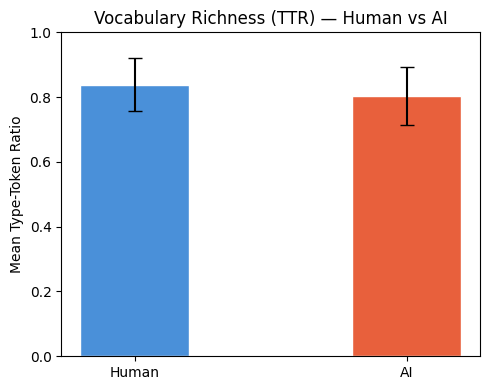

In [ ]:
# TTR by class — collect sample to driver to keep computation fast
ttr_results = []
for label_val, label_name in [(0, 'Human'), (1, 'AI')]:
    sample = (
        preprocessed_df
        .filter(F.col(LABEL_COL) == label_val)
        .select('clean_text')
        .sample(fraction=0.5, seed=42)
        .toPandas()
    )
    ttrs = [
        len(set(row.split())) / max(len(row.split()), 1)
        for row in sample['clean_text'].fillna('')
        if len(row.split()) > 5
    ]
    ttr_results.append({
        'class': label_name,
        'mean_TTR': round(np.mean(ttrs), 4),
        'std_TTR':  round(np.std(ttrs),  4),
        'n_docs':   len(ttrs),
    })

ttr_df = pd.DataFrame(ttr_results)
print('── Vocabulary Richness (mean doc-level TTR) ──')
print(ttr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(ttr_df['class'], ttr_df['mean_TTR'],
              color=['#4A90D9', '#E8603C'], edgecolor='white', width=0.4)
ax.errorbar(ttr_df['class'], ttr_df['mean_TTR'], yerr=ttr_df['std_TTR'],
            fmt='none', color='black', capsize=5)
ax.set_ylim(0, 1); ax.set_ylabel('Mean Type-Token Ratio')
ax.set_title('Vocabulary Richness (TTR) — Human vs AI')
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'ttr_comparison.png'), dpi=150)
plt.show()


## 7. Text Length Distribution

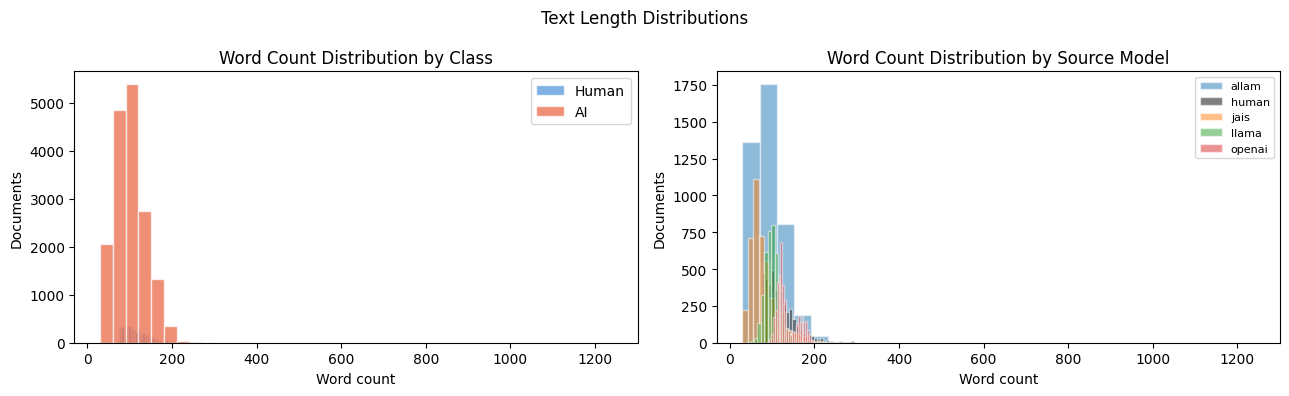

In [ ]:
length_pdf = (
    preprocessed_df
    .withColumn('word_count', F.size(F.split(F.col(TEXT_COL), r'\s+')))
    .select('word_count', LABEL_COL, SOURCE_COL, SPLIT_COL)
    .sample(fraction=0.5, seed=42)
    .toPandas()
)
length_pdf['label_name'] = length_pdf[LABEL_COL].map({0: 'Human', 1: 'AI'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=100)

# By class
for label_name, color in [('Human', '#4A90D9'), ('AI', '#E8603C')]:
    sub = length_pdf[length_pdf['label_name'] == label_name]
    axes[0].hist(sub['word_count'], bins=40, alpha=0.7, label=label_name, color=color, edgecolor='white')
axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Documents')
axes[0].set_title('Word Count Distribution by Class')
axes[0].legend()

# By source model
for model in sorted(length_pdf[SOURCE_COL].unique()):
    sub = length_pdf[length_pdf[SOURCE_COL] == model]
    axes[1].hist(sub['word_count'], bins=30, alpha=0.5,
                 label=model, color=MODEL_COLOURS.get(model, 'gray'), edgecolor='white')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('Documents')
axes[1].set_title('Word Count Distribution by Source Model')
axes[1].legend(fontsize=8)

plt.suptitle('Text Length Distributions', fontsize=12)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'text_length_distribution.png'), dpi=150)
plt.show()


## 8. Summary of figures saved

In [ ]:
saved = sorted(FIGURES_DIR.glob('*.png')) + sorted(FIGURES_DIR.glob('*.csv'))
print(f'{len(saved)} EDA artifacts saved to {FIGURES_DIR}:')
for f in saved:
    print(' ', f.name)


29 EDA artifacts saved to /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/reports/figures:
  avg_word_count_by_model_split.png
  confusion_matrices.png
  feature_importances.png
  final_model_comparison.png
  model_comparison_val.png
  ngrams_ai.png
  ngrams_human.png
  ngrams_unigrams_by_polishing.png
  ngrams_unigrams_from_title.png
  ngrams_unigrams_from_title_and_content.png
  scalability_benchmark.png
  stream_throughput.png
  stylometric_importances.png
  text_length_distribution.png
  top_bigrams.png
  top_unigrams.png
  ttr_comparison.png
  wordclouds.png
  wordclouds_by_class.png
  wordclouds_by_split_class.png
  words_per_model.png
  zipf_word_freq_distribution.png
  avg_word_count_table.csv
  batch_vs_stream.csv
  scalability_benchmark.csv
  stream_progress_log.csv
  test_metrics.csv
  top_words_ai.csv
  top_words_human.csv
